In [17]:
import os
print("Current directory:", os.getcwd())


Current directory: D:\Minor_Project


In [18]:
import os
import shutil

project_dir = r"c:\Users\basan\Desktop\project\Minor_Project"

# 1. Point the base_path DIRECTLY inside the d1Certificate folder
base_path = os.path.join(project_dir, "maindataset", "d1Certificate forgery detection")
output_path = os.path.join(project_dir, "dataset_clean")

# 2. Wipe out the old dataset_clean folder completely to avoid mixing old images
shutil.rmtree(output_path, ignore_errors=True)

for split in ["train", "val"]:
    for cls in ["real", "fake"]:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

def process_folder(exact_folder_path, dest_name):
    images_path = os.path.join(exact_folder_path, "images")
    labels_path = os.path.join(exact_folder_path, "labels")

    if not os.path.exists(labels_path):
        print(f"⚠️ WARNING: Directory not found: {labels_path}")
        return

    print(f"Processing: {labels_path} ...")
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            label_file = os.path.join(labels_path, file)
            with open(label_file, "r") as f:
                first_line = f.readline().strip()
            if not first_line:
                continue

            class_id = int(first_line.split()[0])
            dest = "fake" if class_id == 0 else "real" if class_id == 1 else None
            
            image_name = file.replace(".txt", ".jpg")
            image_path = os.path.join(images_path, image_name)

            if dest and os.path.exists(image_path):
                shutil.copy(image_path, os.path.join(output_path, dest_name, dest, image_name))

# 3. Process the fully loaded train and valid splits!
train_path = os.path.join(base_path, "train")
process_folder(train_path, "train")

valid_path = os.path.join(base_path, "valid")
process_folder(valid_path, "val")

print("✅ DONE! Brand new dataset organized securely.")


Processing: c:\Users\basan\Desktop\project\Minor_Project\maindataset\d1Certificate forgery detection\train\labels ...
Processing: c:\Users\basan\Desktop\project\Minor_Project\maindataset\d1Certificate forgery detection\valid\labels ...
✅ DONE! Brand new dataset organized securely.


In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [20]:
"""
TensorFlow (Keras) Training Pipeline for Fake Certificate Detection
"""
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, Rescaling, Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# --- 1. Configuration & Constants ---
# Using Windows-specific formatting for the path
DATASET_PATH = r"D:\DATASET\dataset_clean" 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

def build_and_train_model():
    # --- 2. Load Dataset using image_dataset_from_directory ---
    print("Loading training dataset...")
    train_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "train"),
        shuffle=True,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    print("Loading validation dataset...")
    val_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "val"),
        shuffle=True,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    # Autotune to improve loading performance during training
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

    # --- 3. Preprocessing & Data Augmentation ---
    # As requested: Random flip and small rotation
    data_augmentation = Sequential([
        RandomFlip("horizontal_and_vertical"),
        RandomRotation(0.1),  # Up to 10% rotation
    ], name="data_augmentation")

    # --- 4. Build Model with Transfer Learning ---
    print("Building MobileNetV2 model...")
    # Load MobileNetV2 without its top classification layers
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base model to use as a feature extractor
    base_model.trainable = False

    # Define the final model architecture
    inputs = Input(shape=IMG_SIZE + (3,))
    # Apply Augmentation
    x = data_augmentation(inputs)
    # Apply Normalization (0-1)
    x = Rescaling(1./255)(x)
    # Pass through MobileNetV2
    x = base_model(x, training=False) 
    # Global average pooling to reduce dimensions
    x = GlobalAveragePooling2D()(x)
    # Output layer (sigmoid for binary classification)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    # --- 5. Compile Model ---
    model.compile(
        optimizer=Adam(),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )
    
    model.summary()

    # --- 6. Train Model ---
    print(f"Training for {EPOCHS} epochs...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS
    )

    # --- 7. Plot Accuracy & Loss ---
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.show()

    # --- 8. Save Model ---
    model_path = "fake_certificate_model.h5"
    model.save(model_path)
    print(f"Model saved successfully to '{model_path}'")
    
    return model_path

# --- 9. Predict on Single Image ---
def predict_single_image(model_path, img_path):
    print(f"\nEvaluating single image: {img_path}")
    if not os.path.exists(img_path):
        print("Error: Image path not found!")
        return

    # Load Model
    model = tf.keras.models.load_model(model_path)
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch dimension, (1, 224, 224, 3)
    
    # Predict
    prediction = model.predict(img_array)
    score = prediction[0][0]
    
    print(f"Raw Prediction Probability: {score:.4f}")
    
    # By default `image_dataset_from_directory` processes classes alphabetically ('fake', 'real').
    # Class 0 = fake, Class 1 = real. 
    # So if Sigmoid output > 0.5, it predicts "real".
    if score >= 0.5:
        print("Prediction result: Real Certificate")
    else:
        print("Prediction result: Fake Certificate")


# --- Execution Block ---
# You can execute the pipeline and uncomment the prediction test if you wish
if __name__ == "__main__":
    
    # Call to build, compile, and train
    # saved_model_path = build_and_train_model()
    
    # Test Single Prediction (replace with a real test path)
    # test_image = r"D:\DATASET\dataset_clean\val\fake\test_fake.jpg"
    # predict_single_image(saved_model_path, test_image)
    pass


Loading training dataset...
Found 299 files belonging to 2 classes.


Loading validation dataset...
Found 59 files belonging to 2 classes.
Building MobileNetV2 model...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training for 10 epochs...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.6656 - loss: 0.6487 - val_accuracy: 0.8305 - val_loss: 0.5882
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - accuracy: 0.6756 - loss: 0.6107 - val_accuracy: 0.8475 - val_loss: 0.5674
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step - accuracy: 0.6756 - loss: 0.5863 - val_accuracy: 0.8475 - val_loss: 0.5287
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 424ms/step - accuracy: 0.6756 - loss: 0.5594 - val_accuracy: 0.8475 - val_loss: 0.5319
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 453ms/step - accuracy: 0.7090 - loss: 0.5460 - val_accuracy: 0.8475 - val_loss: 0.5369
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.6957 - loss: 0.5327 - val_accuracy: 0.8475 - val_loss: 0.5047
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 356ms/step - accuracy: 0.7559 - loss: 0.5195 - val_accuracy: 0.8475 - val_loss: 0.4866
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - accuracy: 0.7358 - loss:

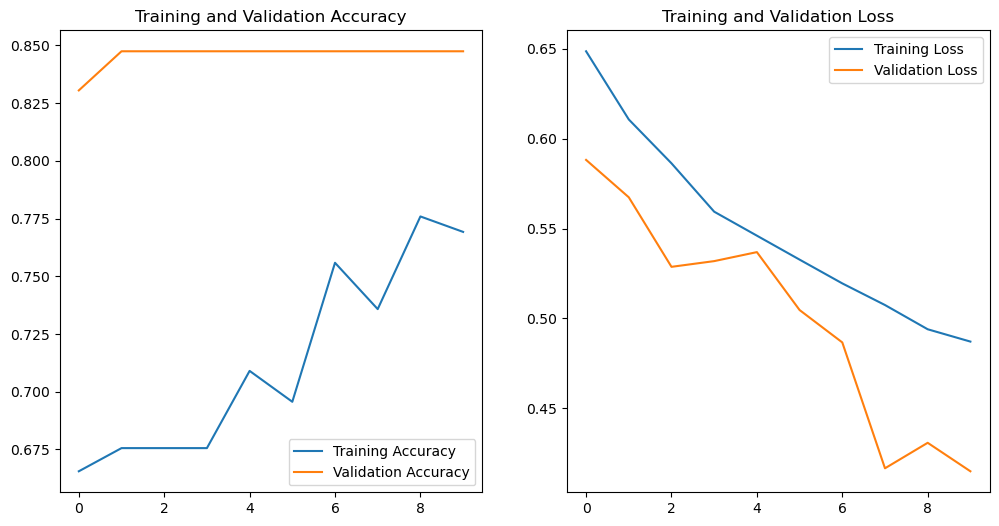

Model saved successfully to 'fake_certificate_model.h5'


In [21]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, Rescaling, Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Using relative paths to avoid WinError 3
DATASET_PATH = r"c:\Users\basan\Desktop\project\Minor_Project\dataset_clean"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

def build_and_train_model():
    print("Loading training dataset...")
    train_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "train"),
        shuffle=True,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    print("Loading validation dataset...")
    val_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "val"),
        shuffle=True,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

    data_augmentation = Sequential([
        RandomFlip("horizontal_and_vertical"),
        RandomRotation(0.1),
    ], name="data_augmentation")

    print("Building MobileNetV2 model...")
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = Rescaling(1./255)(x)
    x = base_model(x, training=False) 
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )
    model.summary()

    print(f"Training for {EPOCHS} epochs...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS
    )

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

    model_path = "fake_certificate_model.h5"
    model.save(model_path)
    print(f"Model saved successfully to '{model_path}'")
    return model_path

def predict_single_image(model_path, img_path):
    print(f"\nEvaluating single image: {img_path}")
    if not os.path.exists(img_path):
        print("Error: Image path not found!")
        return

    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    
    prediction = model.predict(img_array)
    score = prediction[0][0]
    
    print(f"Raw Prediction Probability: {score:.4f}")
    if score >= 0.5:
        print("Prediction result: Real Certificate")
    else:
        print("Prediction result: Fake Certificate")

# Uncomment to train
saved_model_path = build_and_train_model()

